## Filtro Casado

Até este ponto partimos de uma sequência de símbolos, geramos um trem de impulsos cada um representando um dos símbolos e escolhemos um pulso $p(t)$ para formar o sinal analógico que será modulado, transmitido pelo canal e demodulado.

Considerando que o sinal $x(t)$ com amplitude $A_p$ e em um instante $t_0$, ou seja
$$
x_R(t) = A_pp(t - t_0),
$$
sendo a energia do pulso recebido dada po
$$
E_p = \int_{-\infty}^{\infty} |X_r(f)|^2df = A^2\int_{-\infty}^{\infty} |P(f)|^2df 
$$

Na entrada do recepeptor esse sinal é somado ao ruído $n(t)$, e passa por um filtro $h_r(t)$. Nosso objetivo é projetar o filtro para que a recepção seja ótima. Para tanto, vamos medir o sinal recebido em um instante $t  = t_0 + t_d$ que tem amplitude $A$, o objetivo é projetar o filtro para minimizar o valor RMS do ruído. 

Temos que
$$
A = \mathcal{F}^{-1}[H_R(f)X_R(f)]|_{t = t_0 + t_d} = A_P\int_{-\infty}^{\infty} H_R(f)P(f)e^{j\omega t_d}df
$$
e a variância do ruído
$$
\sigma^2 = \int_{-\infty}^{\infty} |H_R(f)|^2N(f)df
$$
e queremos maximizar
$$
\left(\frac{A}{\sigma}\right)^2=A_p^2\frac{\left| \int_{-\infty}^{\infty} H_R(f)X_R(f)e^{j\omega t_d} df\right|^2}{\int_{-\infty}^{\infty} |H_R(f)|^2N(f)df}
$$

Pela desiguladade de Schwartz
$$
\frac{\left|\int_{-\infty}^{\infty} A(f)B^*(f) df\right|^2}{\int_{-\infty}^{\infty} |A(f)|^2N(f)df} \leq \int_{-\infty}^{\infty} |A(f)|^2N(f)df
$$
Comparando as duas equações anteriores podemos escrever
$$
A(f) = H_R(f)\sqrt{N(f)}
$$
e
$$
B^*(f)  = \frac{A_pH_R(f)P(f)e^{j\omega t_d}}{N(f)}
$$
e a desiguldade ser torna igualdade quando $A(f)$ é proporcional a $B(f)$, Fazendo $A(f) = kB(f)/K$ temos
$$
\left(\frac{A}{\sigma}\right)^2 = A_p^2\int_{-\infty}^{\infty}\frac{|P(f)|^2}{N(f)}df
$$

No caso do ruído branco $N(f) = N_0/2$ e 
$$
\left(\frac{A}{\sigma}\right)^2 = 2\frac{A_p^2}{N_0}\int_{-\infty}^{\infty}|P(f)|^2 df =  \frac{2E_p}{N_0}
$$
e a resposta ao impulso do filtro se torna
$$
h(t) = \mathcal{F}^{-1} \left[\frac{2K}{N_0}P^*(f)e^{-j\omega t_d}\right] = \frac{2K}{N_0}p(t_d - t)
$$
conhecido como **Filtro Casado**.

No código abaixo está uma implementação para demonstrar a utilização do Filtro Casado em um sistema com ruído Gaussiano.

Nessa demonstração não se considera o atraso $t_d$, sincronização perfeita entre transmissor e receptor, e que se utiliza um pulso quadrado.

In [7]:
## Gera um sinal (sig) composto por uma sequência de pulsos quadrados
## cujas amplitudes são especificadas pelo vetor Ampl e que cada pulso
# tem 128 amostras.
# É adicionado um ruído Gaussiano, com vairância pot (referência à potência)
#
# Edmar C. Gurjão. Versão 29/02/2023

from scipy import signal
import numpy as np

# Amplitudes dos pulsos
Ampl = [0., 1., 1., 0., 1., 0., 0., 1.]

# Gera o sinal
sig = np.repeat(Ampl, 128)

#Adiciona o ruído com variância pot
pot = 100;
sig_noise = sig + np.sqrt(pot)*np.random.randn(len(sig))

# Aplica a correlação
corr = signal.correlate(sig_noise, np.ones(128), mode='same') / 128

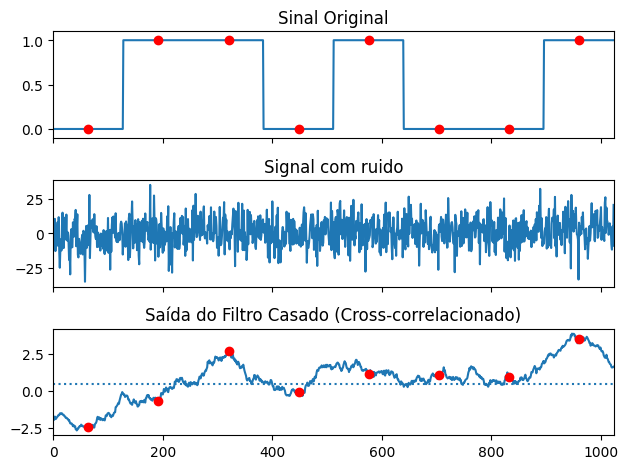

In [8]:
import matplotlib.pyplot as plt

clock = np.arange(64, len(sig), 128)

fig, (ax_orig, ax_noise, ax_corr) = plt.subplots(3, 1, sharex=True)
ax_orig.plot(sig)
ax_orig.plot(clock, sig[clock], 'ro')
ax_orig.set_title('Sinal Original')
ax_noise.plot(sig_noise)
ax_noise.set_title('Signal com ruido')
ax_corr.plot(corr)
ax_corr.plot(clock, corr[clock], 'ro')
ax_corr.axhline(0.5, ls=':')
ax_corr.set_title('Saída do Filtro Casado (Cross-correlacionado)')
ax_orig.margins(0, 0.1)
fig.tight_layout()
#fig.show()

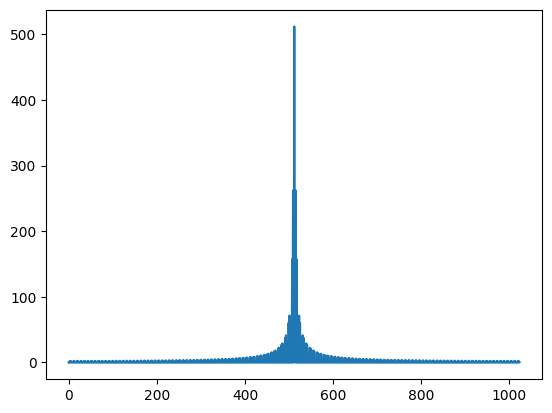

In [26]:
## Desenha o espectro de frequências do sinal (sig) gerado

SIG_f = np.fft.fft(sig)

# Faz o deslocamento para melhorar a visualização
SIG_f_shift = np.fft.fftshift(SIG_f)

plt.plot(np.abs(SIG_f_shift))

Consideremos agora que será calculado o valor
$$r_x = \int_{-\infty}^{\infty}r(t)x(t)dt,$$ sendo $r(t)$ o sinal recebido e $x(t)$ um sinal a nossa escolha.

Se fizermos $h(t) = x(T - \tau)$ temos um filtro casaod com o sinal $x(t)$. Aplicando $r(t)$ a esse filtro temos
$$ y(t) = r(t)*h(t) = \int_{-\infty}^{\infty}r(\tau)h(T-\tau)d\tau =  \int_{-\infty}^{\infty}r(\tau)x(T-t + \tau)d\tau $$
e medindo $y(T)$ ontemos
$$r_x = y(T) = \int_{-\infty}^{\infty}r(t)x(t)dt,$$
ou seja, o instante ótimo para amostrar $y(t)$ é em $t = T$.

### Espectro do Filtro Casado

Como $h(t) = p(T - t)$, sua transformada de Fourier é dada por
$$ H(f) = P^*(f)e^{-j2\pi fT}$$
ou seja, a magnitude do espectro do filtro casado é igual a do pulso $|H(f)| = |P(f)|$, e a fase é o negativo da fase de $P(f)$ deslocada de $2\pi f T$. 